```
RIAWELC_dataset/DB - Copy/
├── training/
│   ├── CR/ (Cracks)
│   ├── LP/ (Lack of Penetration)
│   ├── PO/ (Porosity)
│   └── ND/ (No Defect)
├── validation/
│   ├── CR/
│   ├── LP/
│   ├── PO/
│   └── ND/
└── testing/
    ├── CR/
    ├── LP/
    ├── PO/
    └── ND/
```

## Part 1: Install Required Libraries

In [1]:
# Install PyTorch and other required packages
# !pip install torch torchvision torchaudio numpy pandas matplotlib scikit-learn opencv-python 
!pip install pillow -q
print("Installation complete!")

Installation complete!



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## Part 2: Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.7.1+cu118
Device: cuda
GPU: NVIDIA RTX 5000 Ada Generation


## Part 3: Set Dataset Path and Configuration

In [16]:
# UPDATE THIS PATH to your dataset location
DATASET_BASE_PATH = r"C:\Users\mp29984\Desktop\RIAWELC\RIAWELC\Dataset_partitioned\RIAWELC_dataset\DB - Copy"
DATASET_BASE_PATH = os.path.abspath(DATASET_BASE_PATH)

# Define paths
TRAINING_PATH = os.path.join(DATASET_BASE_PATH, "training")
VALIDATION_PATH = os.path.join(DATASET_BASE_PATH, "validation")
TESTING_PATH = os.path.join(DATASET_BASE_PATH, "testing")

# Define class names (after renaming)
CLASS_NAMES = ['CR', 'LP', 'PO', 'ND']  # Cracks, Lack of Penetration, Porosity, No Defect
CLASS_LABELS = {
    'CR': 'Cracks',
    'LP': 'Lack of Penetration',
    'PO': 'Porosity',
    'ND': 'No Defect'
}

# Configuration
CONFIG = {
    'image_size': 224,
    'batch_size': 32,
    'learning_rate': 0.001,
    'epochs': 50,
    'num_classes': 4,
    'device': device,
    'subset_size': 100  # Number of images per class to use
}

print(f"Training path: {TRAINING_PATH}")
print(f"Validation path: {VALIDATION_PATH}")
print(f"Testing path: {TESTING_PATH}")
print(f"\nClass names: {CLASS_NAMES}")
print(f"\nConfig: {CONFIG}")

Training path: C:\Users\mp29984\Desktop\RIAWELC\RIAWELC\Dataset_partitioned\RIAWELC_dataset\DB - Copy\training
Validation path: C:\Users\mp29984\Desktop\RIAWELC\RIAWELC\Dataset_partitioned\RIAWELC_dataset\DB - Copy\validation
Testing path: C:\Users\mp29984\Desktop\RIAWELC\RIAWELC\Dataset_partitioned\RIAWELC_dataset\DB - Copy\testing

Class names: ['CR', 'LP', 'PO', 'ND']

Config: {'image_size': 224, 'batch_size': 32, 'learning_rate': 0.001, 'epochs': 50, 'num_classes': 4, 'device': device(type='cuda'), 'subset_size': 100}


## Part 4: Verify and Explore Dataset Structure

In [17]:
# Check if paths exist
print("Checking dataset structure...\n")

if os.path.exists(TRAINING_PATH):
    print(f"✓ Training path exists")
    print(f"  Contents: {sorted(os.listdir(TRAINING_PATH))}")
else:
    print(f"✗ Training path NOT found: {TRAINING_PATH}")

if os.path.exists(VALIDATION_PATH):
    print(f"\n✓ Validation path exists")
    print(f"  Contents: {sorted(os.listdir(VALIDATION_PATH))}")
else:
    print(f"\n✗ Validation path NOT found: {VALIDATION_PATH}")

if os.path.exists(TESTING_PATH):
    print(f"\n✓ Testing path exists")
    print(f"  Contents: {sorted(os.listdir(TESTING_PATH))}")
else:
    print(f"\n✗ Testing path NOT found: {TESTING_PATH}")

# Count images in each defect class
print("\n" + "="*70)
print("Image Count by Defect Class:")
print("="*70)

for class_name in CLASS_NAMES:
    train_path = os.path.join(TRAINING_PATH, class_name)
    val_path = os.path.join(VALIDATION_PATH, class_name)
    test_path = os.path.join(TESTING_PATH, class_name)
    
    train_count = len([f for f in os.listdir(train_path) if f.endswith('.png')]) if os.path.exists(train_path) else 0
    val_count = len([f for f in os.listdir(val_path) if f.endswith('.png')]) if os.path.exists(val_path) else 0
    test_count = len([f for f in os.listdir(test_path) if f.endswith('.png')]) if os.path.exists(test_path) else 0
    total = train_count + val_count + test_count
    
    print(f"{CLASS_LABELS[class_name]:25} | Train: {train_count:6} | Val: {val_count:6} | Test: {test_count:6} | Total: {total:6}")

Checking dataset structure...

✓ Training path exists
  Contents: ['CR', 'LP', 'ND', 'PO']

✓ Validation path exists
  Contents: ['CR', 'LP', 'ND', 'PO']

✓ Testing path exists
  Contents: ['CR', 'LP', 'ND', 'PO']

Image Count by Defect Class:
Cracks                    | Train:   4962 | Val:   1908 | Test:    765 | Total:   7635
Lack of Penetration       | Train:   4108 | Val:   1580 | Test:    632 | Total:   6320
Porosity                  | Train:   2893 | Val:   1113 | Test:    446 | Total:   4452
No Defect                 | Train:   3900 | Val:   1500 | Test:    600 | Total:   6000


## Part 5: Create Custom Dataset Class

In [18]:
class RIAWELCDataset(Dataset):
    """
    Custom PyTorch Dataset for RIAWELC weld defect images
    """
    def __init__(self, root_path, class_names, transform=None, subset_size=None):
        """
        Args:
            root_path: Path to training, validation or testing folder
            class_names: List of class folder names
            transform: Image transformations to apply
            subset_size: Number of images per class to use (for sampling)
        """
        self.root_path = root_path
        self.class_names = class_names
        self.transform = transform
        self.subset_size = subset_size
        self.images = []
        self.labels = []
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
        
        # Load all images
        self._load_images()
    
    def _load_images(self):
        """Load all image paths and labels with optional subset sampling"""
        for class_name in self.class_names:
            class_path = os.path.join(self.root_path, class_name)
            if os.path.exists(class_path):
                image_files = [f for f in os.listdir(class_path) if f.endswith('.png')]
                
                # If subset_size is specified, randomly sample images
                if self.subset_size and len(image_files) > self.subset_size:
                    image_files = np.random.choice(image_files, self.subset_size, replace=False)
                
                for img_file in image_files:
                    self.images.append(os.path.join(class_path, img_file))
                    self.labels.append(self.class_to_idx[class_name])
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # Load image
        img_path = self.images[idx]
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if image is None:
            raise ValueError(f"Failed to load image: {img_path}")
        
        # Resize if needed
        if image.shape != (CONFIG['image_size'], CONFIG['image_size']):
            image = cv2.resize(image, (CONFIG['image_size'], CONFIG['image_size']))
        
        # Convert to 3-channel (RGB) for PyTorch compatibility
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        
        # Apply transformations
        if self.transform:
            image = self.transform(Image.fromarray(image))
        else:
            # Default transformation
            image = transforms.ToTensor()(Image.fromarray(image))
        
        label = self.labels[idx]
        return image, label

print("RIAWELCDataset class created successfully!")

RIAWELCDataset class created successfully!


## Part 6: Create Data Transformations

In [19]:
# Define data transformations
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_test_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Data transformations created!")

Data transformations created!


## Part 7: Load Datasets and Create DataLoaders

In [20]:
# Load datasets with subset sampling
print("Loading datasets...")

# Load training dataset
train_dataset = RIAWELCDataset(
    TRAINING_PATH, 
    CLASS_NAMES, 
    transform=train_transform,
    subset_size=CONFIG['subset_size']
)

# Load validation dataset
val_dataset = RIAWELCDataset(
    VALIDATION_PATH, 
    CLASS_NAMES, 
    transform=val_test_transform,
    subset_size=CONFIG['subset_size']
)

# Load testing dataset
test_dataset = RIAWELCDataset(
    TESTING_PATH, 
    CLASS_NAMES, 
    transform=val_test_transform,
    subset_size=CONFIG['subset_size']
)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Testing dataset size: {len(test_dataset)}")

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

print(f"\nDataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

Loading datasets...
Training dataset size: 400
Validation dataset size: 400
Testing dataset size: 400

DataLoaders created:
  Train batches: 13
  Validation batches: 13
  Test batches: 13


## Part 8: Visualize Sample Images

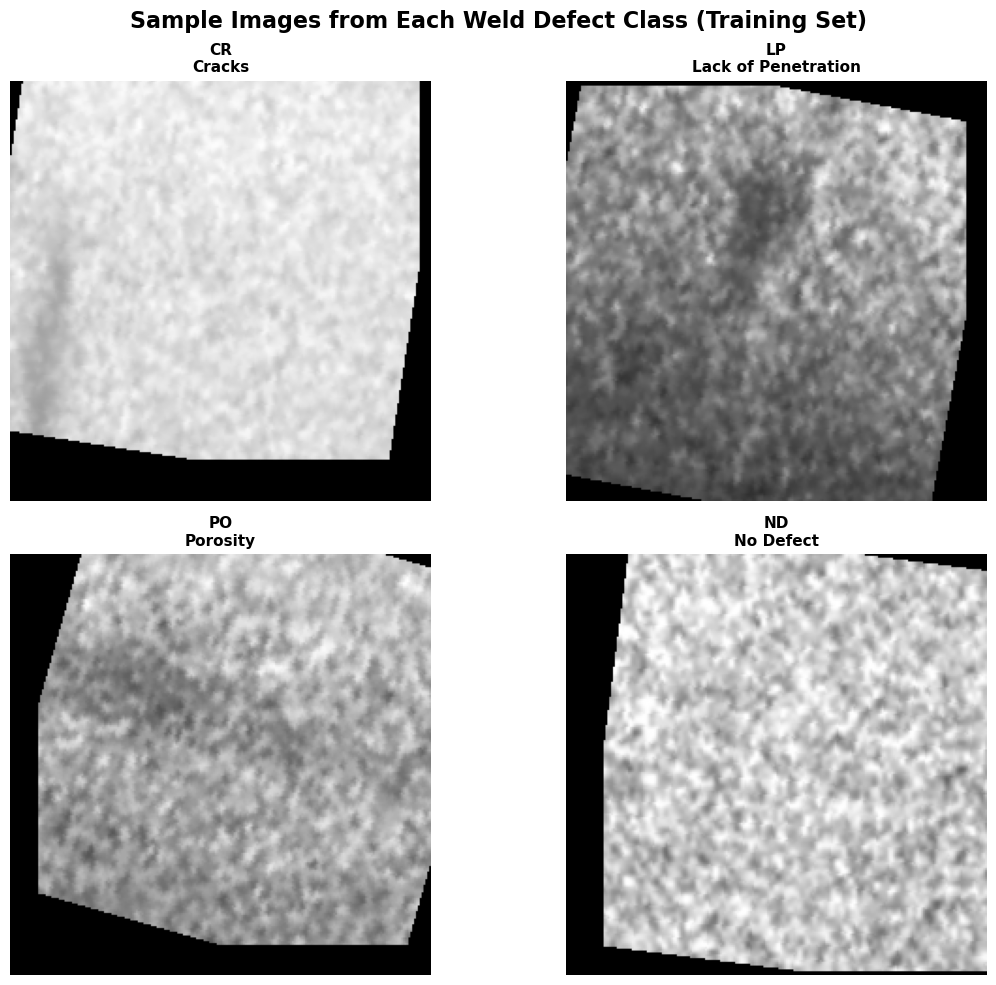

Sample images displayed!


In [21]:
# Display sample images from training set
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Sample Images from Each Weld Defect Class (Training Set)', 
             fontsize=16, fontweight='bold')

# Get one image per class
class_samples = {}
for img, label in train_dataset:
    if label not in class_samples:
        class_samples[label] = img
    if len(class_samples) == CONFIG['num_classes']:
        break

# Display
for class_idx, ax in enumerate(axes.flat):
    if class_idx in class_samples:
        img = class_samples[class_idx]
        # Denormalize for display
        img_display = (img * 0.5 + 0.5).numpy()
        img_display = np.transpose(img_display, (1, 2, 0))
        img_display = np.mean(img_display, axis=2)  # Convert to grayscale for display
        
        class_name = CLASS_NAMES[class_idx]
        ax.imshow(img_display, cmap='gray')
        ax.set_title(f"{class_name}\n{CLASS_LABELS[class_name]}", fontweight='bold', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("Sample images displayed!")

## Part 9: Visualize Class Distribution

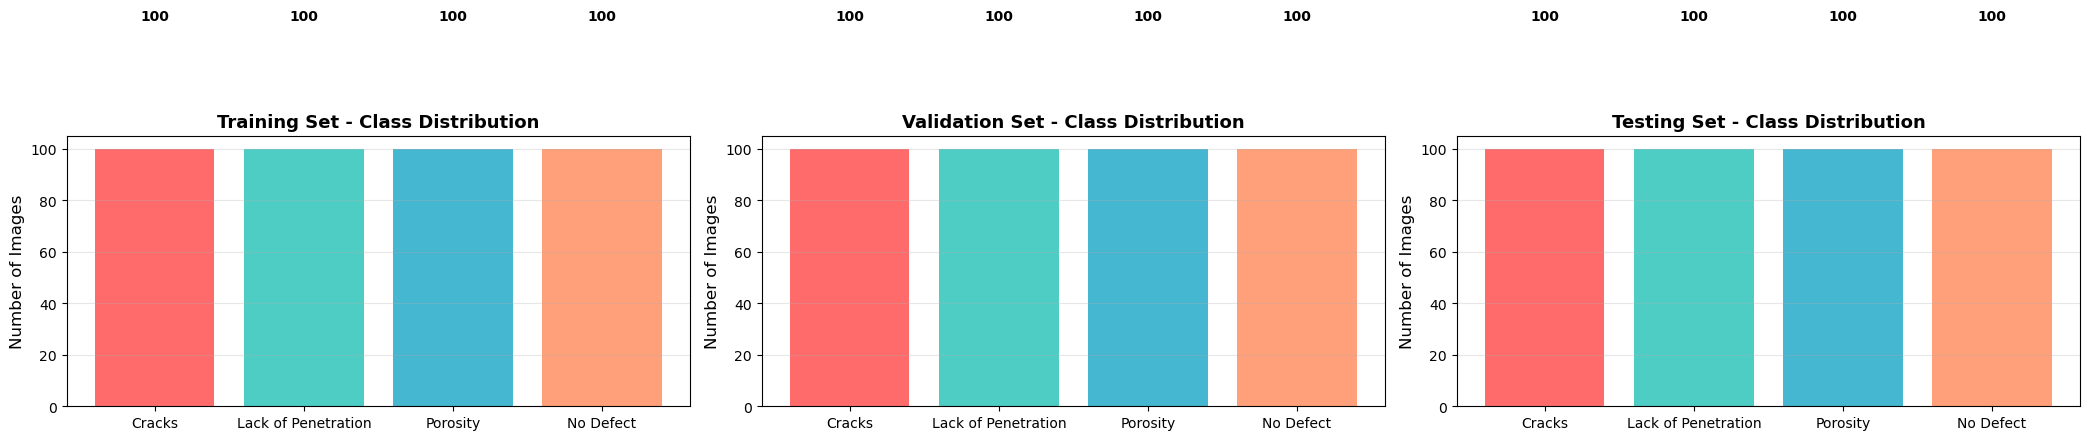


Class Distribution Summary:
Training: {'Cracks': 100, 'Lack of Penetration': 100, 'Porosity': 100, 'No Defect': 100}
Validation: {'Cracks': 100, 'Lack of Penetration': 100, 'Porosity': 100, 'No Defect': 100}
Testing:  {'Cracks': 100, 'Lack of Penetration': 100, 'Porosity': 100, 'No Defect': 100}


In [22]:
# Calculate class distribution
train_class_counts = [0] * CONFIG['num_classes']
val_class_counts = [0] * CONFIG['num_classes']
test_class_counts = [0] * CONFIG['num_classes']

for _, label in train_dataset:
    train_class_counts[label] += 1

for _, label in val_dataset:
    val_class_counts[label] += 1

for _, label in test_dataset:
    test_class_counts[label] += 1

# Plot class distribution
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
class_labels_display = [CLASS_LABELS[name] for name in CLASS_NAMES]

# Training distribution
axes[0].bar(class_labels_display, train_class_counts, color=colors)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('Training Set - Class Distribution', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, count in enumerate(train_class_counts):
    axes[0].text(i, count + 50, str(count), ha='center', fontweight='bold')

# Validation distribution
axes[1].bar(class_labels_display, val_class_counts, color=colors)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].set_title('Validation Set - Class Distribution', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, count in enumerate(val_class_counts):
    axes[1].text(i, count + 50, str(count), ha='center', fontweight='bold')

# Testing distribution
axes[2].bar(class_labels_display, test_class_counts, color=colors)
axes[2].set_ylabel('Number of Images', fontsize=12)
axes[2].set_title('Testing Set - Class Distribution', fontsize=13, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for i, count in enumerate(test_class_counts):
    axes[2].text(i, count + 50, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nClass Distribution Summary:")
print(f"Training: {dict(zip(class_labels_display, train_class_counts))}")
print(f"Validation: {dict(zip(class_labels_display, val_class_counts))}")
print(f"Testing:  {dict(zip(class_labels_display, test_class_counts))}")

## Part 10: Define CNN Model

In [23]:
class WeldDefectCNN(nn.Module):
    """
    Convolutional Neural Network for weld defect classification
    """
    def __init__(self, num_classes=4):
        super(WeldDefectCNN, self).__init__()
        
        # Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        
        # Block 2
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout2 = nn.Dropout(0.25)
        
        # Block 3
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.dropout3 = nn.Dropout(0.25)
        
        # Block 4
        self.conv7 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn7 = nn.BatchNorm2d(256)
        self.conv8 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn8 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(2, 2)
        self.dropout4 = nn.Dropout(0.25)
        
        # Flatten and Dense layers
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.dropout5 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 256)
        self.dropout6 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(256, num_classes)
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # Block 1
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Block 2
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Block 3
        x = self.relu(self.bn5(self.conv5(x)))
        x = self.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)
        x = self.dropout3(x)
        
        # Block 4
        x = self.relu(self.bn7(self.conv7(x)))
        x = self.relu(self.bn8(self.conv8(x)))
        x = self.pool4(x)
        x = self.dropout4(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Dense layers
        x = self.relu(self.fc1(x))
        x = self.dropout5(x)
        x = self.relu(self.fc2(x))
        x = self.dropout6(x)
        x = self.fc3(x)
        
        return x

# Create model
model = WeldDefectCNN(num_classes=CONFIG['num_classes']).to(device)
print("Model created!")
print(f"\nModel Summary:")
print(model)

Model created!

Model Summary:
WeldDefectCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.25, inplace=False)
  (conv5): Conv2d(64, 128, ke

## Part 11: Define Loss Function and Optimizer

In [25]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

print("Loss function: CrossEntropyLoss")
print(f"Optimizer: Adam (lr={CONFIG['learning_rate']})")
print("Scheduler: ReduceLROnPlateau")

Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau


## Part 12: Define Training Functions

In [26]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train for one epoch
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if (batch_idx + 1) % 10 == 0:
            print(f'  Batch [{batch_idx + 1}/{len(train_loader)}], Loss: {loss.item():.4f}')
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    """
    Validate model
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

print("Training functions defined!")

Training functions defined!


## Part 13: Train the Model

In [27]:
# Training loop
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0
patience = 10
patience_counter = 0

print(f"Training for {CONFIG['epochs']} epochs...\n")

for epoch in range(CONFIG['epochs']):
    print(f"Epoch [{epoch+1}/{CONFIG['epochs']}]")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%\n')
    
    # Learning rate scheduler
    scheduler.step(val_acc)
    
    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print("\nTraining completed!")

Training for 50 epochs...

Epoch [1/50]
  Batch [10/13], Loss: 4.4583
  Batch [10/13], Loss: 4.4583
  Train Loss: 5.6770, Train Acc: 29.50%
  Val Loss: 1.6158, Val Acc: 25.00%

Epoch [2/50]
  Train Loss: 5.6770, Train Acc: 29.50%
  Val Loss: 1.6158, Val Acc: 25.00%

Epoch [2/50]
  Batch [10/13], Loss: 2.8186
  Batch [10/13], Loss: 2.8186
  Train Loss: 2.9240, Train Acc: 21.75%
  Val Loss: 1.4227, Val Acc: 25.00%

Epoch [3/50]
  Train Loss: 2.9240, Train Acc: 21.75%
  Val Loss: 1.4227, Val Acc: 25.00%

Epoch [3/50]
  Batch [10/13], Loss: 1.5866
  Batch [10/13], Loss: 1.5866
  Train Loss: 1.8637, Train Acc: 21.00%
  Val Loss: 1.3938, Val Acc: 24.00%

Epoch [4/50]
  Train Loss: 1.8637, Train Acc: 21.00%
  Val Loss: 1.3938, Val Acc: 24.00%

Epoch [4/50]
  Batch [10/13], Loss: 1.5564
  Batch [10/13], Loss: 1.5564
  Train Loss: 1.6628, Train Acc: 22.50%
  Val Loss: 1.3889, Val Acc: 25.00%

Epoch [5/50]
  Train Loss: 1.6628, Train Acc: 22.50%
  Val Loss: 1.3889, Val Acc: 25.00%

Epoch [5/50]


## Part 14: Plot Training History

In [ ]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history['train_acc'], label='Training Accuracy', linewidth=2, color='#2E86AB')
ax1.plot(history['val_acc'], label='Validation Accuracy', linewidth=2, color='#A23B72')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Loss
ax2.plot(history['train_loss'], label='Training Loss', linewidth=2, color='#2E86AB')
ax2.plot(history['val_loss'], label='Validation Loss', linewidth=2, color='#A23B72')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print best metrics
best_epoch = np.argmax(history['val_acc'])
print(f"Best epoch: {best_epoch + 1}")
print(f"Best validation accuracy: {history['val_acc'][best_epoch]:.2f}%")

## Part 15: Load Best Model and Evaluate on Test Set

In [ ]:
# Load best model
model.load_state_dict(torch.load('best_model.pth'))
print("Best model loaded!")

# Evaluate on test set
model.eval()
test_correct = 0
test_total = 0
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

test_accuracy = 100 * test_correct / test_total

print("\n" + "="*60)
print("TEST SET PERFORMANCE")
print("="*60)
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Correct: {test_correct}/{test_total}")

## Part 16: Classification Report

In [ ]:
# Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
target_names = [CLASS_LABELS[name] for name in CLASS_NAMES]
print(classification_report(y_true, y_pred, target_names=target_names))

## Part 17: Confusion Matrix

In [ ]:
# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names,
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 18: Visualize Predictions

In [ ]:
# Get predictions with probabilities
model.eval()
y_pred_probs_all = []
test_images = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        
        y_pred_probs_all.extend(probs.cpu().numpy())
        test_images.extend(images.cpu().numpy())
        test_labels.extend(labels.numpy())

# Visualize some predictions
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle('Model Predictions on Test Set', fontsize=16, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    if idx < min(9, len(test_images)):
        img = test_images[idx]
        true_label_idx = test_labels[idx]
        pred_probs = y_pred_probs_all[idx]
        pred_label_idx = np.argmax(pred_probs)
        confidence = np.max(pred_probs) * 100
        
        true_label = CLASS_LABELS[CLASS_NAMES[true_label_idx]]
        pred_label = CLASS_LABELS[CLASS_NAMES[pred_label_idx]]
        
        # Color green if correct, red if incorrect
        color = 'green' if true_label_idx == pred_label_idx else 'red'
        
        # Denormalize and convert to display format
        img_display = (img * 0.5 + 0.5)
        img_display = np.transpose(img_display, (1, 2, 0))
        img_display = np.mean(img_display, axis=2)  # Grayscale
        
        ax.imshow(img_display, cmap='gray')
        title_text = f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%'
        ax.set_title(title_text, color=color, fontweight='bold', fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()

## Part 19: Save the Model

In [ ]:
# Save model
torch.save(model.state_dict(), 'riawelc_pytorch_model.pth')
print("Model weights saved as 'riawelc_pytorch_model.pth'")

# Save entire model
torch.save(model, 'riawelc_pytorch_model_full.pth')
print("Full model saved as 'riawelc_pytorch_model_full.pth'")

# Save class mapping
import json
class_mapping = {
    'class_names': CLASS_NAMES,
    'class_labels': CLASS_LABELS
}
with open('class_mapping.json', 'w') as f:
    json.dump(class_mapping, f, indent=2)
print("Class mapping saved as 'class_mapping.json'")

## Part 20: Predict on New Images

In [ ]:
def predict_single_image(image_path, model, device, classes, labels):
    """
    Predict the class of a single radiographic weld image
    
    Args:
        image_path: Path to the PNG image
        model: Trained PyTorch model
        device: Device (cpu or cuda)
        classes: List of class names
        labels: Dictionary mapping class names to full labels
    
    Returns:
        Dictionary with prediction results
    """
    # Load and preprocess image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        return {'error': f'Could not load image from {image_path}'}
    
    # Resize and convert to RGB
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    
    # Apply transformations
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    img_tensor = transform(Image.fromarray(img)).unsqueeze(0).to(device)
    
    # Make prediction
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)[0]
        predicted_idx = torch.argmax(probs).item()
        confidence = probs[predicted_idx].item() * 100
    
    # Get all probabilities
    all_probs = {labels[classes[i]]: probs[i].item()*100 for i in range(len(classes))}
    
    return {
        'predicted_class': classes[predicted_idx],
        'predicted_label': labels[classes[predicted_idx]],
        'confidence': confidence,
        'all_probabilities': all_probs
    }

# Example: Test on one image from the test set
print("Testing prediction function on a test image...\n")
test_image_path = os.path.join(TESTING_PATH, CLASS_NAMES[0], 
                               os.listdir(os.path.join(TESTING_PATH, CLASS_NAMES[0]))[0])

result = predict_single_image(test_image_path, model, device, CLASS_NAMES, CLASS_LABELS)

print(f"Predicted Class: {result['predicted_class']}")
print(f"Label: {result['predicted_label']}")
print(f"Confidence: {result['confidence']:.2f}%")
print(f"\nAll Probabilities:")
for label, prob in result['all_probabilities'].items():
    print(f"  {label:30}: {prob:.2f}%")

## Part 21: Summary & Next Steps

### What You've Built:
1. **Custom PyTorch Dataset Class** - Loads images from your folder structure
2. **CNN Model** - 4-block convolutional neural network with batch normalization
3. **Data Augmentation** - Rotation, translation, flipping for better generalization
4. **Training Pipeline** - With early stopping and learning rate scheduling
5. **Complete Evaluation** - Accuracy, precision, recall, F1-score, confusion matrix
6. **Prediction Function** - To classify new radiographic images

### Advantages of PyTorch:
- **Dynamic computation graphs** - Easier debugging
- **More control** - Fine-grained control over model training
- **Research-friendly** - Better for experimentation
- **Better GPU support** - Optimized for GPU acceleration

### To Improve Performance:
- **Transfer Learning**: Use pre-trained models like ResNet50, EfficientNet
- **Data Augmentation**: More aggressive augmentation if limited data
- **Hyperparameter Tuning**: Adjust learning rate, batch size, dropout
- **Class Weights**: Use weighted loss for imbalanced classes
- **Ensemble Methods**: Combine multiple models

### Quick Tips:
- Save your best model during training
- Use learning rate scheduling to improve convergence
- Monitor validation accuracy for early stopping
- Visualize predictions to understand model errors